# Projekt tymoteusz hanusiak

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


data = yf.download("^GSPC", start="2000-01-01", progress=False)


data.head()


YF.download() has changed argument auto_adjust default to True


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000


In [2]:
data['returns'] = (data['Close'] - data['Close'].shift(1)) /  data['Close'].shift(1) 



In [3]:
data=data.dropna()

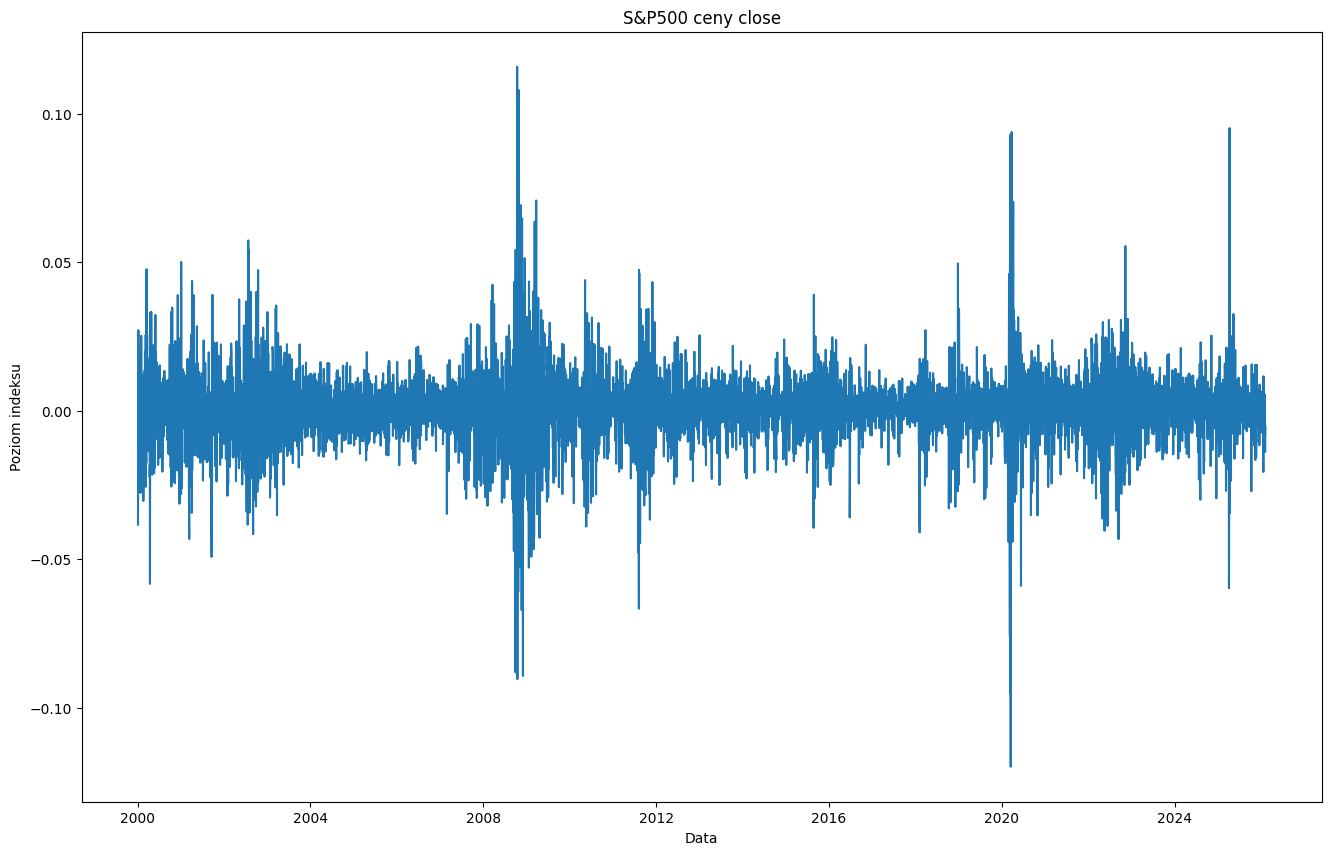

In [44]:
plt.figure(figsize=(16,10))
plt.plot(data['returns'] )
plt.title("S&P500 ceny close")
plt.xlabel("Data")
plt.ylabel("Poziom indeksu")
plt.show()


# testowanie stacjonarnosci

In [5]:
data['returns']

Date
2000-01-04   -0.038345
2000-01-05    0.001922
2000-01-06    0.000956
2000-01-07    0.027090
2000-01-10    0.011190
                ...   
2026-01-30   -0.004302
2026-02-02    0.005391
2026-02-03   -0.008404
2026-02-04   -0.005072
2026-02-05   -0.013752
Name: returns, Length: 6562, dtype: float64

## KPSS 

In [24]:
from statsmodels.tsa.stattools import adfuller, kpss

returns = data['returns']

kpss_result = kpss(returns, regression='c', nlags='auto')


print(f"p-value: {kpss_result[1]:.4f}")
print(" Crt values:", kpss_result[3])


p-value: 0.0753
 Crt values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


# ADF 

In [25]:
adf_result = adfuller(returns, autolag='AIC')


In [26]:
print(f"p-value: {adf_result[1]:.4f}")
print("Crit Val:", adf_result[4])


p-value: 0.0000
Crit Val: {'1%': -3.431352125191296, '5%': -2.8619828537883376, '10%': -2.5670057276807974}


- W obu przypadkach dane sa stacjonarne (brak pierwiastka jednostkowego) bo w ADF (zakladmy signif level 5% w both testach) p-value jest below 5%

- I w KPSS wartosc jest powyzej 5% sifnic level p-value 

## Opis badanej zmiennej i źródło danych

- Dane do analizy to dzienne proste stopy zwrotu indeksu S&P 500, który obejmuje 500 najwiekszych społek notowanych na rynku US  i jest powszechnie wykorzystywany jako wskaznik kondycji gospodarki US. 

- W analizie wykorzystalem dzienne ceny zamkniecia indeksu od stycznia 2000 roku.

- Dane pobralem z Yahoo Finance biblioteką yfinance. 

## Przygotowanie danych i uzasadnienie metody

- Indeksy giełdowe charakteryzują się niestacjonarnościa, wynikającą z trendu oraz heteroscedasticity. Z tego powodu wzialem stopy zwrotu ktore sa niemalze zawsze stacjonarne.

- Liczenie stop zwrotu pozwala usunąć trend deterministyczny oraz w pewnym stopniu stabilizuje wariancję szeregu.

- Stacjonarnosc otrzymanego szeregu zweryfikowałem empirycznie przy użyciu testów ADF (Augmented Dickey–Fuller) oraz KPSS (Kwiatkowski–Phillips–Schmidt–Shin). Wyniki obu testów potwierdziły, że proste stopy zwrotu indeksu S&P 500 mogą są stacjonarne.

# Analiza podstawowa

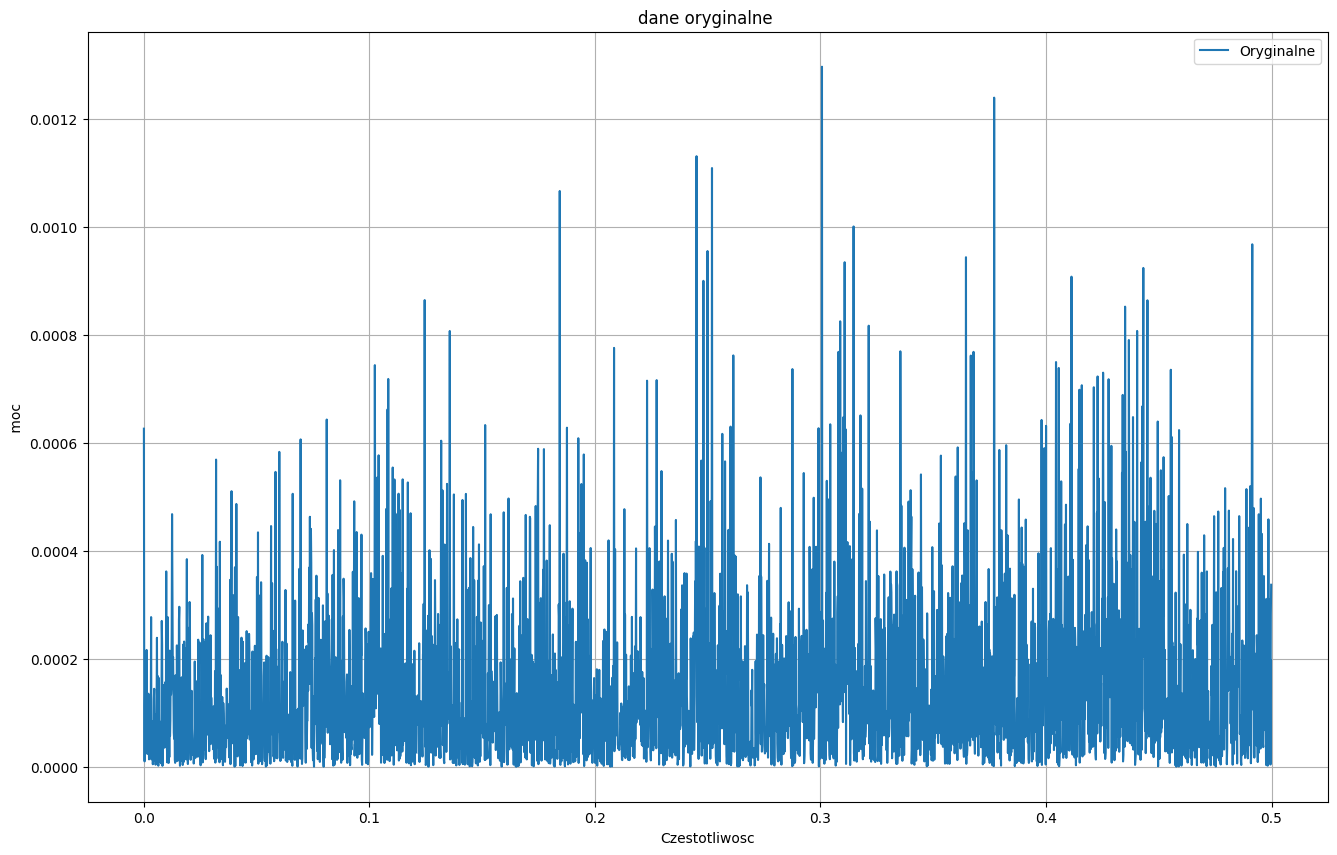

In [43]:
import numpy as np
import matplotlib.pyplot as plt

x = data['returns'].dropna().values
N = len(x)

X = np.fft.fft(x)
periodogram = (1/N) * np.abs(X)**2

x_centered = x - np.mean(x)

X_c = np.fft.fft(x_centered)

periodogram_c = (1/N) * np.abs(X_c)**2

freq = np.fft.fftfreq(N)

plt.figure(figsize=(16,10))

plt.plot(freq[:N//2], periodogram[:N//2], label='Oryginalne')

plt.title("dane oryginalne ")

plt.xlabel("Czestotliwosc")

plt.ylabel(" moc ")

plt.legend()

plt.grid(True)

plt.show()


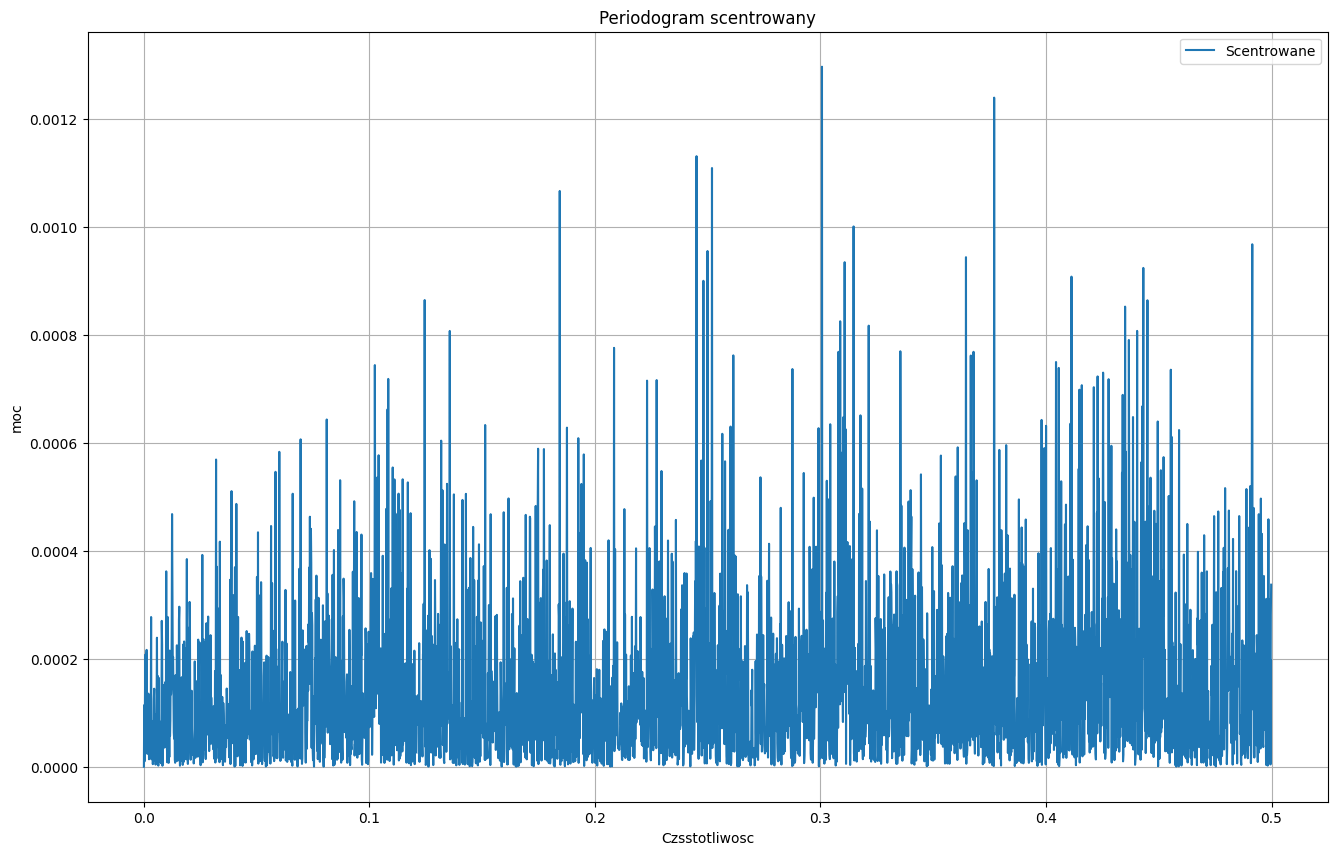

In [42]:
plt.figure(figsize=(16,10))
plt.plot(freq[:N//2], periodogram_c[:N//2], label='Scentrowane')

plt.title("Periodogram scentrowany")

plt.xlabel("Czsstotliwosc")

plt.ylabel("moc")

plt.legend()
plt.grid(True)
plt.show()

## opis 

- W przypadku prostych stóp zwrotu różnice pomiędzy periodogramem danych oryginalnych i scentrowanych są praktycznie niewidoczne. 
- Wynika to z faktu, że średnia stóp zwrotu jest bliska zeru, a zatem składowa stała sygnału ma pomijalny wpływ na widmo częstotliwościowe. 
- Scentrowanie usuwa składową o częstotliwości zerowej, jednak w analizowanym przypadku jej znaczenie było niewielkie, co skutkuje bardzo podobnym kształtem obu periodogramów (niemalze identycznym).

## czesc 2 

- wyznaczneie tych podzielnych przez nautralny okres i niepodzielny przez naturalny okres.

In [33]:
import numpy as np
import matplotlib.pyplot as plt

T = 5 # dla tygodnia

x = data['returns'].dropna().values
N = len(x)

# podzielne
N_div = (N // T) * T
x_div = x[:N_div]

# niepodzielne
x_nodiv = x[:N_div + 1]


## periodogram podzielne

In [37]:
X_div = np.fft.fft(x_div)
periodogram_div = (1 / len(x_div)) * np.abs(X_div)**2
freq_div = np.fft.fftfreq(len(x_div))


## periodogram niepodzielne

In [38]:
X_nodiv = np.fft.fft(x_nodiv)
periodogram_nodiv = (1 / len(x_nodiv)) * np.abs(X_nodiv)**2
freq_nodiv = np.fft.fftfreq(len(x_nodiv))


## porownanie 

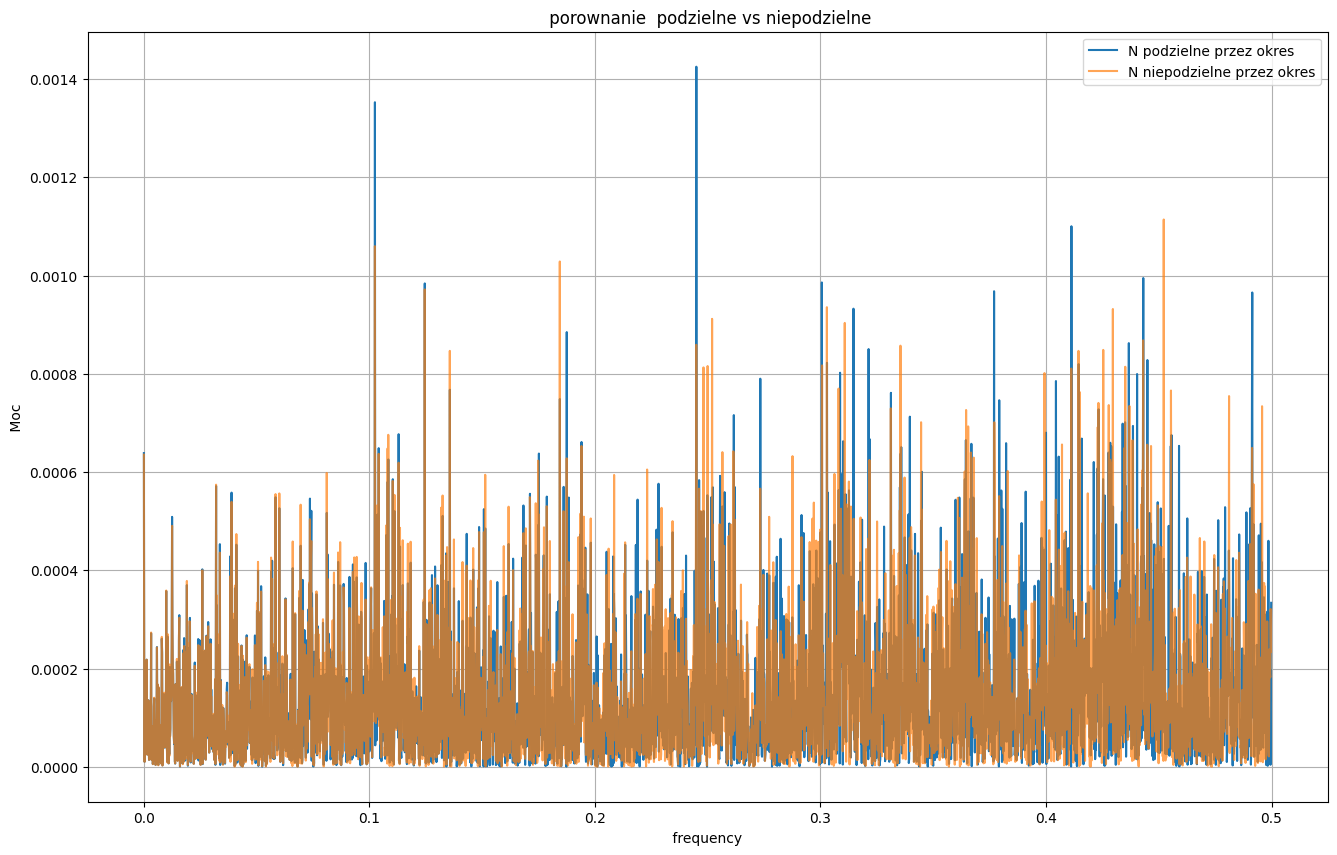

In [41]:
plt.figure(figsize=(16,10))

plt.plot(freq_div[:len(freq_div)//2],
         periodogram_div[:len(periodogram_div)//2],
         label='N podzielne przez okres')

plt.plot(freq_nodiv[:len(freq_nodiv)//2],
         periodogram_nodiv[:len(periodogram_nodiv)//2],
         label='N niepodzielne przez okres',
         alpha=0.7)
plt.xlabel(" frequency ")
plt.ylabel(" Moc ")
plt.title(" porownanie  podzielne vs niepodzielne")
plt.legend()
plt.grid(True)
plt.show()



- W obu przypadkach ogólny kształt widma jest bardzo podobny co wskazuje na brak silnych deterministycznych cykli w analizowanym szeregu stóp zwrotu. Jest to zgodne z charakterystyka danych finansowych w których stopy zwrotu mają średnią bliską zeru i nie wykazują regularnej sezonowości.

- można jednak zauważyć że dla próby o długości n podzielnej przez przyjęty okres lokalne maksima mocy są nieco wyraźniejsze i lepiej zlokalizowane. Oznacza to ze wariancja stóp zwrotu jest w większym stopniu skoncentrowana w okreslonych częstotliwościach.

- W przypadku próby o długości n niepodzielnej przez okres widmo jest bardziej rozmyte a wariancja rozklada się na szerszy zakres czestotliwości. Jest to efekt wycieku  (spectral leakage), wynikający z niedopasowania długości próby do naturalnego okresu danych.


# Periodogram

In [11]:
x = (data['returns'] - data['returns'].mean()).dropna().values
N = len(x)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# periodogram naiwny
X = np.fft.fft(x)
P_raw = (1/N) * np.abs(X)**2
freq = np.fft.fftfreq(N)

P_raw = P_raw[:N//2]
freq = freq[:N//2]

# 95% przedział ufności 
alpha = 0.05
lower = 2 * P_raw / chi2.ppf(1 - alpha/2, df=2)
upper = 2 * P_raw / chi2.ppf(alpha/2, df=2)


## metoda welcha

In [13]:
from scipy.signal import welch

freq_w, P_welch = welch(
    x,
    window='hann',
    nperseg=N//8,
    scaling='density'
)


## okno daniella 

In [14]:
def daniell_smooth(P, m):
    kernel = np.ones(2*m + 1) / (2*m + 1)
    return np.convolve(P, kernel, mode='same')

P_daniell_1 = daniell_smooth(P_raw, m=3)


In [15]:
P_daniell_multi = daniell_smooth(
    daniell_smooth(P_raw, m=3),
    m=3
)


In [16]:
K = 5
M = N // K

P_segments = []

for i in range(K):
    seg = x[i*M:(i+1)*M]
    X_seg = np.fft.fft(seg)
    P_seg = (1/M) * np.abs(X_seg)**2
    P_segments.append(P_seg[:M//2])

P_manual = np.mean(P_segments, axis=0)
freq_manual = np.fft.fftfreq(M)[:M//2]


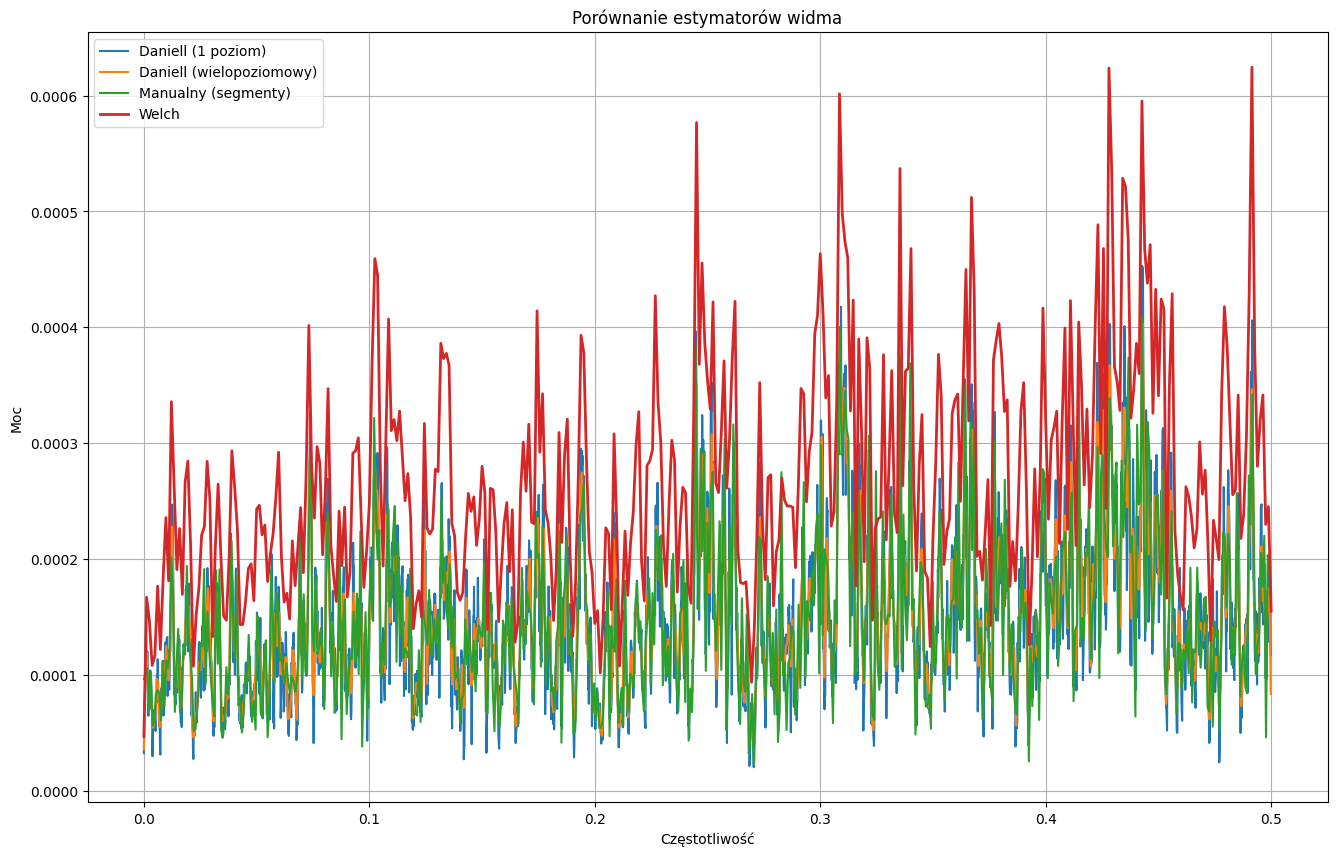

In [ ]:
plt.figure(figsize=(16,10))

plt.plot(freq, P_daniell_1, label='Daniell (1 poziom)')
plt.plot(freq, P_daniell_multi, label='Daniell (wielopoziomowy)')
plt.plot(freq_manual, P_manual, label='Manualny (segmenty)')
plt.plot(freq_w, P_welch, label='Welch', linewidth=2)

plt.xlabel("Częstotliwość")
plt.ylabel("Moc")
plt.title("Porównanie estymatorów widma")
plt.legend()
plt.grid(True)
plt.show()


# surowy osobno

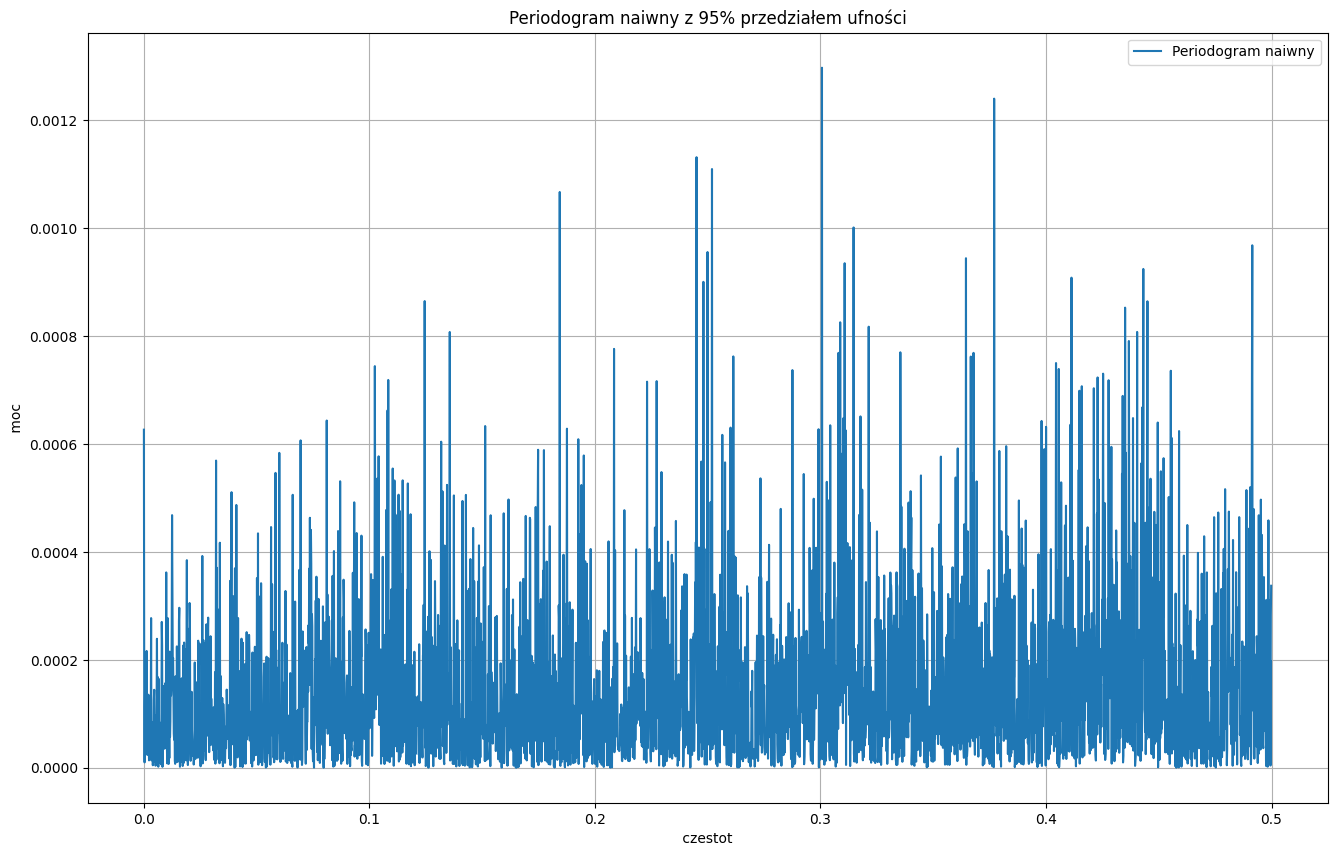

In [ ]:
from scipy.stats import chi2

X = np.fft.fft(x)
P_raw_full = (1/N) * np.abs(X)**2
freq_full = np.fft.fftfreq(N)

half = N // 2
P_raw = P_raw_full[:half]
freq = freq_full[:half]

alpha = 0.05
lower = 2 * P_raw / chi2.ppf(1 - alpha/2, df=2)
upper = 2 * P_raw / chi2.ppf(alpha/2, df=2)

plt.figure(figsize=(16,10))
plt.plot(freq, P_raw, label='Periodogram naiwny')
#plt.plot(freq, lower,  label='dolne 95% CI') 
#plt.plot(freq, upper, label='gorne 95% CI')
plt.xlabel(" czestot ")
plt.ylabel(" moc ")
plt.title("Periodogram naiwny z 95% przedziałem ufności")
plt.legend()
plt.grid(True)


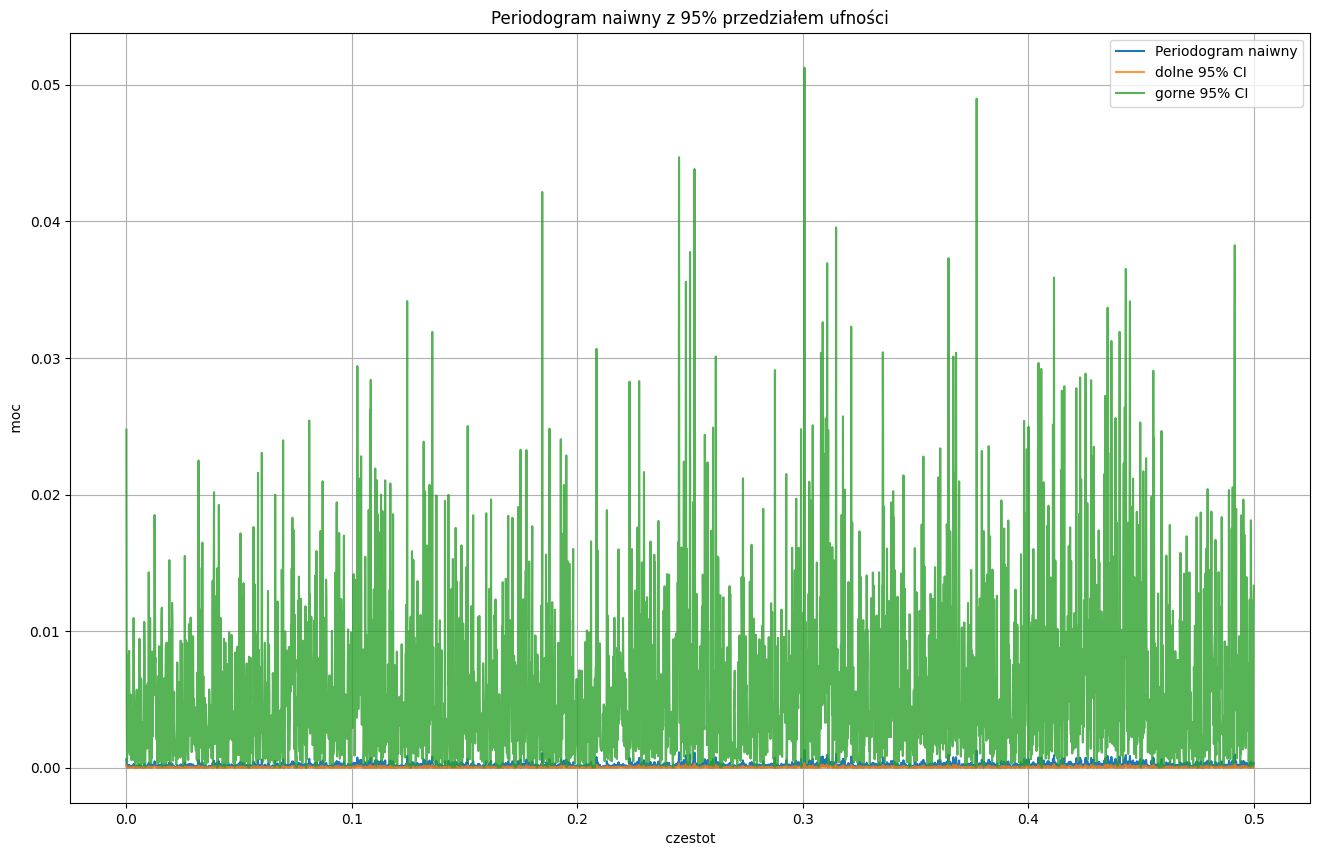

In [53]:
from scipy.stats import chi2

X = np.fft.fft(x)
P_raw_full = (1/N) * np.abs(X)**2
freq_full = np.fft.fftfreq(N)

half = N // 2
P_raw = P_raw_full[:half]
freq = freq_full[:half]

alpha = 0.05
lower = 2 * P_raw / chi2.ppf(1 - alpha/2, df=2)
upper = 2 * P_raw / chi2.ppf(alpha/2, df=2)

plt.figure(figsize=(16,10))
plt.plot(freq, P_raw, label='Periodogram naiwny')
plt.plot(freq, lower, alpha=0.8, label='dolne 95% CI') 
plt.plot(freq, upper, alpha=0.8 ,label='gorne 95% CI')
plt.xlabel(" czestot ")
plt.ylabel(" moc ")
plt.title("Periodogram naiwny z 95% przedziałem ufności")
plt.legend()
plt.grid(True)


- przedzialu ufnosci dosyc mocno psuja wizualizacje 

## opis naiwny 

Na wykresie przedstawiłem surowy (naiwny) periodogram wraz z 95% przedziałem ufnosci wyznaczonym na podstawie rozkładu chi-kwadrat. Zauważalne są bardzo szerokie i silnie asymetryczne przedzialy ufnosci, co wskazuje na bardzo duza wariancję tego estymatora.

Tak duża niepewnosc estymacji sprawia ze surowy periodogram ma ograniczoną użytecznosc interpretacyjną, poniewaz utrudnia jednoznaczną identyfikacje struktury czestotliwościowej szeregu. Jest to zgodne z teorią według której naiwny periodogram nie jest estymatorem zgodnym widma a jego wariancja nie maleje wraz ze wzrostem liczby obserwacji.

Metody takie jak wygładzanie oknem Daniella, uśrednianie segmentów czy metoda Welcha, pozwolą na istotne obniżenie wariancji estymatora kosztem częstotliwości.

## opis reszta

- (brak surowego reszta periodogramow jest bez niego bardziej widoczna)

- Surowy periodogram cechuje się bardzo dużą wariancją, co utrudnia identyfikację struktury częstotliwościowej szeregu. 
- Zastosowanie wygładzania metodą Daniella prowadzi do wyraźnego obniżenia wariancji estymatora,
- przy czym wygładzanie wielopoziomowe daje najbardziej stabilne widmo kosztem pewnej utraty rozdzielczości częstotliwościowej.

- Uśrednianie periodogramów po rozłącznych podokresach również skutecznie redukuje wariancję,
- jednak wymaga podziału próby i zmniejsza efektywną liczbę obserwacji. 
- Metoda Welcha zapewnia korzystny kompromis pomiędzy redukcją wariancji a zachowaniem rozdzielczości widma i prowadzi do najbardziej czytelnego estymatora spośród analizowanych metod.

# Analiza danych niekompletnych 

## losowe usuniecie obserwacji 

In [18]:

x_full = (data['returns'] - data['returns'].mean()).dropna().values
N = len(x_full)

t_full = np.arange(N)

np.random.seed(42)
mask = np.random.rand(N) > 0.3   

x_missing = x_full[mask]
t_missing = t_full[mask]


In [19]:
N_miss = len(x_missing)
X_miss = np.fft.fft(x_missing)
P_naive = (1/N_miss) * np.abs(X_miss)**2
freq_naive = np.fft.fftfreq(N_miss)

P_naive = P_naive[:N_miss//2]
freq_naive = freq_naive[:N_miss//2]


## perdiodogram Lomba–Scargle’a

In [20]:
from astropy.timeseries import LombScargle

freq_ls = np.linspace(0.001, 0.5, 2000)

ls = LombScargle(t_missing, x_missing)
power_ls = ls.power(freq_ls)

power_05 = ls.false_alarm_level(0.05)


## Wykres: naiwny vs Lomb–Scargle + poziom istotności

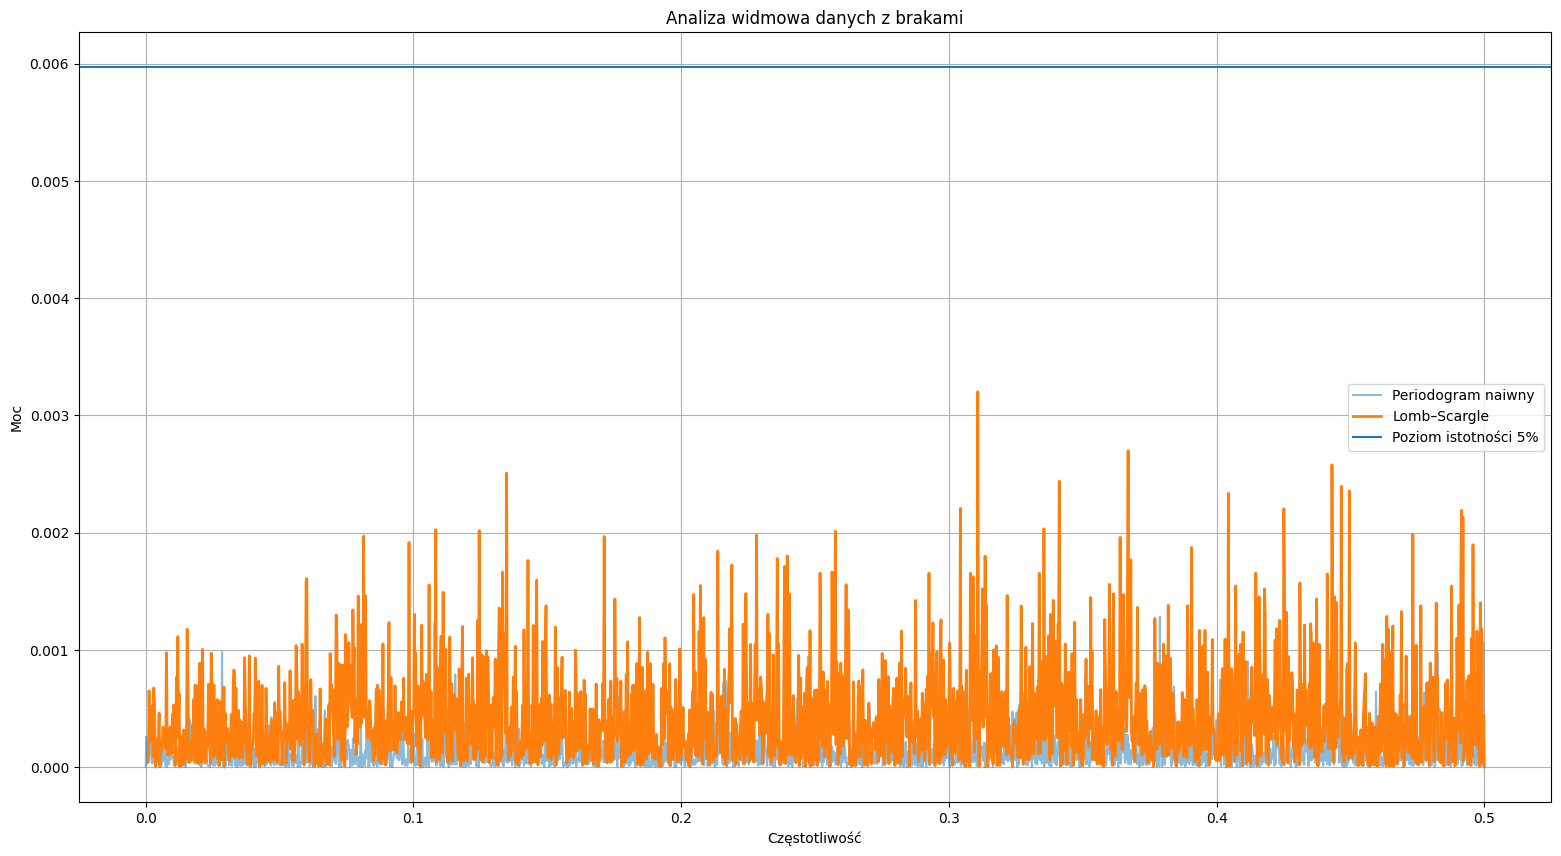

In [54]:

plt.figure(figsize=(19,10))

plt.plot(freq_naive, P_naive, label='Periodogram naiwny', alpha=0.5)
plt.plot(freq_ls, power_ls, label='Lomb–Scargle', linewidth=2)
plt.axhline(power_05, label='Poziom istotności 5%')

plt.xlabel("Częstotliwość")
plt.ylabel("Moc")
plt.title("Analiza widmowa danych z brakami")
plt.legend()
plt.grid(True)
plt.show()


- to 5% ( na wykresie 0.006) to funkcja z bibilioteki pythona wylicza, nie umialem tego poprawic.

# signif level 5% 

Po losowym usunięciu około 30% obserwacji z szeregu czasowego przeprowadziłem analizę widmową z wykorzystaniem periodogramu naiwnego oraz periodogramu Lomba–Scargle’a. Na wykresie dodatkowo zaznaczyłem poziom istotności statystycznej 5%.

W przypadku periodogramu naiwnego obserwuję widmo o bardzo niskiej mocy i wysokim poziomie szumu. Wynika to z faktu, że klasyczna dyskretna transformata Fouriera zakłada równomierne próbkowanie w czasie, które w obecności braków danych nie jest spełnione. W efekcie uzyskany periodogram nie dostarcza wiarygodnych informacji o strukturze częstotliwościowej szeregu.

Zastosowanie periodogramu Lomba–Scargle’a, który jest przystosowany do danych nieregularnie próbkowanych, prowadzi do bardziej stabilnego oszacowania widma. Pomimo występowania lokalnych pików mocy w różnych częstotliwościach, żaden z nich nie przekracza poziomu istotności statystycznej 5%, zaznaczonego na wykresie linią przerywaną.

Oznacza to, że w analizowanym szeregu, nawet po uwzględnieniu braków danych, nie występują statystycznie istotne składowe cykliczne. Wynik ten jest spójny z wcześniejszą analizą pełnych danych i potwierdza, że proste stopy zwrotu indeksu S&P 500 nie wykazują trwałych cykli okresowych, a ich dynamika ma w przeważającej mierze charakter losowy.